# Разведочный анализ с использованием pandas

Кольчурин Андрей Николавеич

студент физико-математического института,

направления радиофизика,

группы ФМ/О РФЗ-1-2022 НБ

Разведочный анализ данных (англ. exploratory data analysis, EDA) — анализ основных свойств данных, нахождение в них общих закономерностей, распределений и аномалий, построение начальных моделей, зачастую с использованием инструментов визуализации. Это понятие введено математиком Джоном Тьюки, который сформулировал цели такого анализа следующим образом:



*   максимальное «проникновение» в данные
*   выявление основных структур
*   выбор наиболее важных переменных
*   обнаружение отклонений и аномалий
*   проверка основных гипотез
*   разработка начальных моделей












Предварительная подготовка данных включает в себя очистку, отбор экземпляров, нормализацию, преобразование данных, выделение признаков, отбор признаков. Результатом предварительной обработки данных является конечный тренировочный набор.

Методы предварительной обработки данных:

*   Очистка данных используется для обнаружения, исправления или удаления ошибочных записей в наборе данных.
*   Нормализация данных используется для стандартизации диапазона значений независимых переменных или признаков данных (например, сведение к интервалам  [0,1]  или  [−1,+1] ).
*   Нормализация данных используется для стандартизации диапазона значений независимых переменных или признаков данных (например, сведение к интервалам  [0,1]  или  [−1,+1] ).
*   Выделение признаков используется для преобразования входных данных в набор признаков, которые они хорошо представляют.
*  Уплотнение данных используется для преобразования числовых данных в исправленный, упорядоченный и упрощённый вид. Это помогает уменьшить количество и/или размерность данных.





In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()  # устанавливаем seaborn по умолчанию для отрисовки графиков

Попробуем разобрать с набором данных "**Прогноз выживаемости пациентов сциррозом**"

Цирроз возникает из-за длительного повреждения печени, что приводит к обширным рубцовым образованиям, часто вызванным такими состояниями, как гепатит или хроническое употребление алкоголя. Предоставленные данные взяты из исследования первичного билиарного цирроза (ПБК) печени, проведённого в клинике Майо с 1974 по 1984 год.

Используя 17 клинических признаков можно прогнозировать выживаемость пациентов с циррозом печени. Условия выживаемости включают 0 = D (смерть), 1 = C (цензурировано), 2 = CL (цензурировано из-за пересадки печени).


In [ ]:
from google.colab import drive

drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
train = pd.read_csv('/content/drive/MyDrive/cirrhosis.csv')

In [ ]:
train.head()

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


 **Описание полей**
*   ID - уникальный идентификатор пациента.

*  N_Days - количество дней между регистрацией и
более ранним сроком смерти, трансплантации или
анализа исследования.

*   Status - статус пациента ( D (смерть), C (цензурировано), CL (цензурировано из-за пересадки печени)).

*  Drug - тип препарата (D-пеницилламина или плацебо).

*   Age - возраст.

*   Sex - пол: M (мужской), F (женский).

*   Ascites - наличие асцитов ( N (Нет) или Y (Да)).

*  Hepatomegaly - наличие гепатомегалии ( N (Нет) или Y (Да)).

*   Spiders - присутствие пауков ( N (Нет) или Y (Да)).

*   Edema - Наличие отёка ( N (отёка нет и нет диуретической терапии при отёке), S (отёк присутствует без диуретиков или отек, проходящий диуретиками), или Y (отёк несмотря на диуретическую терапию)).

*   Bilirubin - Сывороточный билирубин.

*   Cholesterol - Сывороточный холестерин.

*   Albumin - Альбумин.

*   Copper - моча, медь.

*   Alk_Phos - щелочная фосфатаза.

*   SGOT

*   Tryglicerides - триглицериды.


*   Platelets - Тромбоциты на куб.

*   Prothrombin - протромбиновое время.

*   Stage - Гистологическая стадия заболевания (1, 2, 3 или 4).






Продолжаем исследовать обучающий набор данных. Посмотрим на общую статистику числовых данных.

In [ ]:
train.describe()

,ID,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
count,418.000000,418.000000,418.000000,418.000000,284.000000,418.000000,310.000000,312.000000,312.000000,282.000000,407.000000,416.000000,412.000000
mean,209.500000,1917.782297,18533.351675,3.220813,369.510563,3.497440,97.648387,1982.655769,122.556346,124.702128,257.024570,10.731731,3.024272
std,120.810458,1104.672992,3815.845055,4.407506,231.944545,0.424972,85.613920,2140.388824,56.699525,65.148639,98.325585,1.022000,0.882042
min,1.000000,41.000000,9598.000000,0.300000,120.000000,1.960000,4.000000,289.000000,26.350000,33.000000,62.000000,9.000000,1.000000
25%,105.250000,1092.750000,15644.500000,0.800000,249.500000,3.242500,41.250000,871.500000,80.600000,84.250000,188.500000,10.000000,2.000000
50%,209.500000,1730.000000,18628.000000,1.400000,309.500000,3.530000,73.000000,1259.000000,114.700000,108.000000,251.000000,10.600000,3.000000
75%,313.750000,2613.500000,21272.500000,3.400000,400.000000,3.770000,123.000000,1980.000000,151.900000,151.000000,318.000000,11.100000,4.000000
max,418.000000,4795.000000,28650.000000,28.000000,1775.000000,4.640000,588.000000,13862.400000,457.250000,598.000000,721.000000,18.000000,4.000000


Вспомните, что обозначают эти результаты? Какие предварительные выводы можно сделать из этих данных?

Проанализируем нечисловые данные.

In [ ]:
train.describe(include=['O'])

,Status,Drug,Sex,Ascites,Hepatomegaly,Spiders,Edema
count,418,312,418,312,312,312,418
unique,3,2,2,2,2,2,3
top,C,D-penicillamine,F,N,Y,N,N
freq,232,158,374,288,160,222,354


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             418 non-null    int64  
 1   N_Days         418 non-null    int64  
 2   Status         418 non-null    object 
 3   Drug           312 non-null    object 
 4   Age            418 non-null    int64  
 5   Sex            418 non-null    object 
 6   Ascites        312 non-null    object 
 7   Hepatomegaly   312 non-null    object 
 8   Spiders        312 non-null    object 
 9   Edema          418 non-null    object 
 10  Bilirubin      418 non-null    float64
 11  Cholesterol    284 non-null    float64
 12  Albumin        418 non-null    float64
 13  Copper         310 non-null    float64
 14  Alk_Phos       312 non-null    float64
 15  SGOT           312 non-null    float64
 16  Tryglicerides  282 non-null    float64
 17  Platelets      407 non-null    float64
 18  Prothrombi

Можно сделать вывод.

Четверть пациентов имеет неполный набор клинических и лабораторных данных.

In [ ]:

categorical_features = train.select_dtypes(include=['object', 'category', 'bool']).columns
print("Категориальные признаки:")
print(categorical_features.tolist())
print(f"\nВсего категориальных признаков: {len(categorical_features)}")

Категориальные признаки:
['Status', 'Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema']

Всего категориальных признаков: 7


In [ ]:
train.isnull().sum()

,0
ID,0
N_Days,0
Status,0
Drug,106
Age,0
Sex,0
Ascites,106
Hepatomegaly,106
Spiders,106
Edema,0


По предыдущим данным модно сказать что, 9 столбцов с пропусками >25%.

Липидный профиль (холестерин, триглицериды) отсутствует у ~32% пациентов.
Медь отсутствует у ~26% пациентов.

Ровно 106 пропусков в 6 столбцах — это одни и те же пациенты.
Вероятно, 25.4% пациенты, которые не прошли полное клиническое обследование.

Уберем пациентов с системными пропусками.

In [ ]:
train.dropna(subset=['Drug', 'Ascites', 'Hepatomegaly', 'Spiders', 'Alk_Phos', 'SGOT'], inplace=True)
train.isnull().sum()

,0
ID,0
N_Days,0
Status,0
Drug,0
Age,0
Sex,0
Ascites,0
Hepatomegaly,0
Spiders,0
Edema,0


In [ ]:
train.Cholesterol.describe()

,Cholesterol
count,284.000000
mean,369.510563
std,231.944545
min,120.000000
25%,249.500000
50%,309.500000
75%,400.000000
max,1775.000000


## **Кодирование категориальных признаков**

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder()
train[['Sex', 'Status', 'Drug', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema']] = enc.fit_transform(train[['Sex', 'Status', 'Drug', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema']])
train.head()

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,2.0,0.0,21464,0.0,1.0,1.0,1.0,2.0,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,0.0,0.0,20617,0.0,0.0,1.0,1.0,0.0,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,2.0,0.0,25594,1.0,0.0,0.0,0.0,1.0,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,2.0,0.0,19994,0.0,0.0,1.0,1.0,1.0,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,1.0,1.0,13918,0.0,0.0,1.0,1.0,0.0,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


(array([ 16.,   0.,   0.,  67.,   0.,   0., 120.,   0.,   0., 109.]),
 array([1. , 1.3, 1.6, 1.9, 2.2, 2.5, 2.8, 3.1, 3.4, 3.7, 4. ]),
 <BarContainer object of 10 artists>)

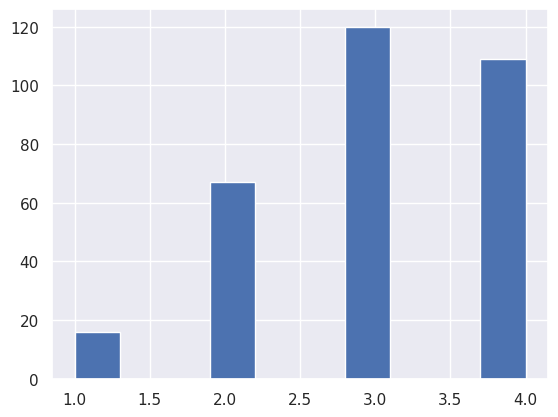

In [ ]:
plt.hist(train['Stage'])

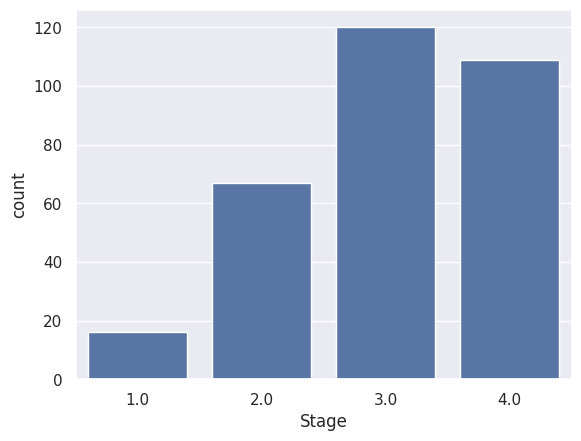

In [ ]:
sns.countplot(x=train["Stage"]);

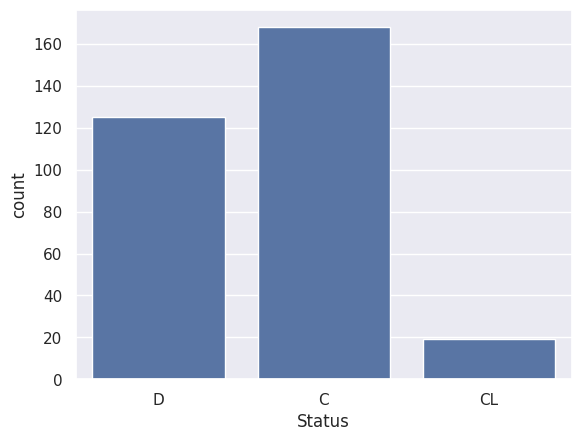

In [ ]:
sns.countplot(x=train["Status"]);

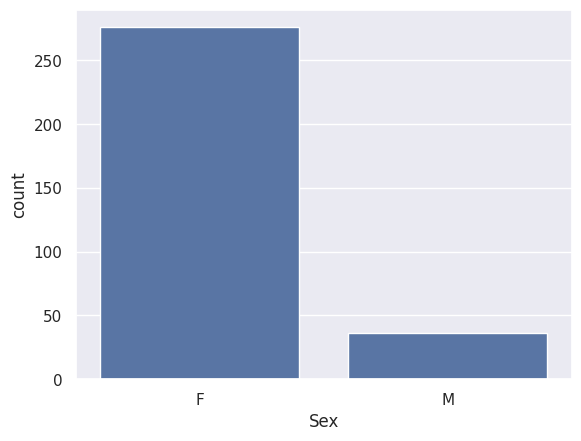

In [ ]:
sns.countplot(x=train["Sex"]);

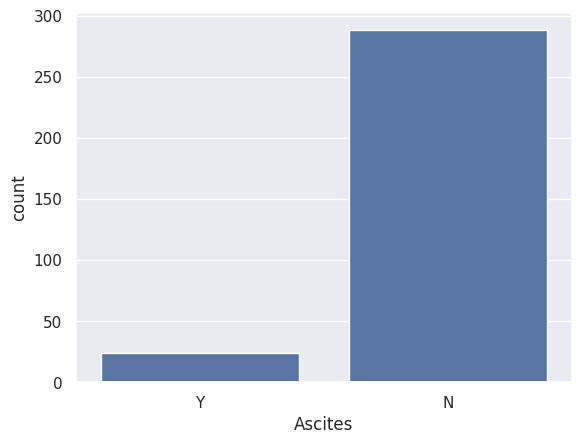

In [ ]:
sns.countplot(x=train["Ascites"]);

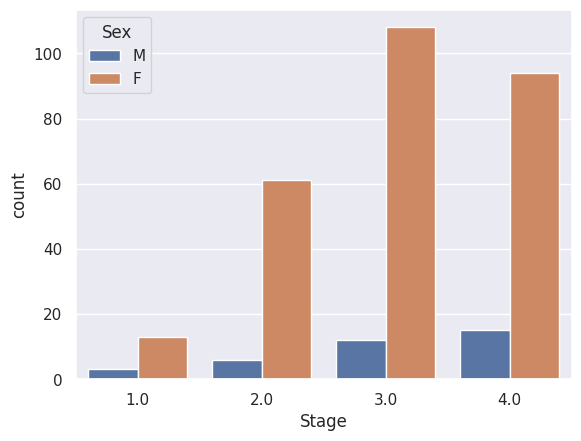

In [ ]:
sns.countplot(data=train, x="Stage", hue='Sex');

In [ ]:
sns.pairplot(train, kind="scatter", hue="Survived");

<Axes: >

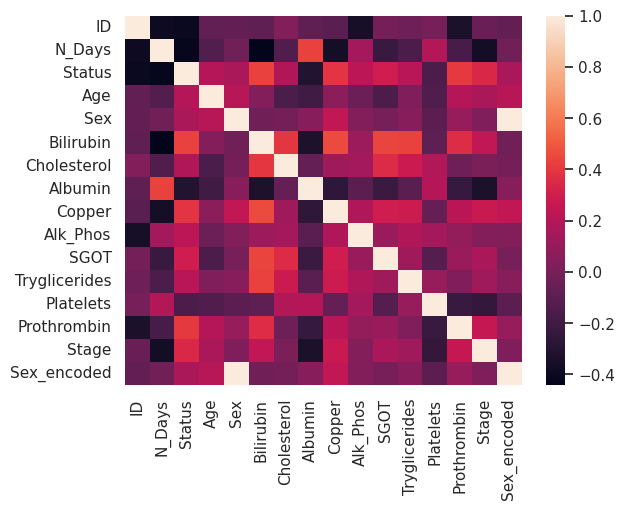

In [ ]:
sns.heatmap(train.corr(numeric_only = True))